In [19]:
import sys
from pathlib import Path

# Add the 'src' directory to sys.path
src_path = Path.cwd().parent / 'src'
sys.path.append(str(src_path))

**PlayAmb MAGLS Implementation**

In [20]:
from playamb.audio.engine.hrtf import HRTF
from playamb.audio.engine.spherical import SphericalHarmonics
from playamb.utils.utils import DEFAULT_HRTF_FILE, resolve_path

import matplotlib.pyplot as plt
import numpy as np
import pyfar as pf

ambi_order = 3
# create our own spherical harmonics
hrtf = HRTF(path=DEFAULT_HRTF_FILE)
sh_magls = SphericalHarmonics(hrtf, ambi_order=ambi_order)
sh_ls =  SphericalHarmonics(hrtf, ambi_order=ambi_order, preprocess='LS')

my_own_magls = pf.Signal(sh_magls.hrir_nm, sh_magls.sampling_rate)

my_own_ls = pf.Signal(sh_ls.hrir_nm, sh_ls.sampling_rate)
print(my_own_ls.cshape)
print(my_own_magls.cshape)

Loaded HRTF from file: C:\Users\giova\Nextcloud\4. Semester\Python & Akustik\Ambisonics player project\ambisonics-player\src\resources\default_hrtf\FABIAN_HRIR_measured_HATO_0.sofa
Using MagLS HRTF Preprocessing
Convert to Spherical Harmonic Signal


c:\Users\giova\Nextcloud\4. Semester\Python & Akustik\Ambisonics player project\ambisonics-player\src\playamb\audio\engine\spherical.py:230: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  alpha, beta, gamma = rotation.as_euler("zyz")


Setting up Spherical Harmonics took 2.22s
Using standard spherical harmonics processing (Least Squares): Simple matrix multiplication.
Convert to Spherical Harmonic Signal
Setting up Spherical Harmonics took 0.10s
(2, 16)
(2, 16)


**Pyshroom MagLS implementation**

In [21]:
from shroom.acoustics.hrtf_processing import magls_hrtf
import shroom.utils.sofa as sofa
import spharpy as sph

# get shroom files. Uses complex SH coefficients
ss = sofa.load_sofa(resolve_path(DEFAULT_HRTF_FILE))
shroom_magls = magls_hrtf(ss, ambi_order)
shroom_ls = ss.copy()
shroom_ls.toSH(ambi_order)


**Thomas Deppisch MagLS implementation**

In [22]:
import scipy.io as scio

deppisch_LSL = scio.loadmat("wLSL.mat")['wLsL'].T
deppisch_LSR = scio.loadmat("wLSR.mat")['wLsR'].T
deppisch_MagLSL = scio.loadmat("wMlsL.mat")['wMlsL'].T
deppisch_MagLSR = scio.loadmat("wMlsR.mat")['wMlsR'].T

# Store channels grouped together in pyfar Signals
deppisch_LS_filter = pf.Signal([deppisch_LSL, deppisch_LSR], 48e3)
deppisch_MagLS_filter = pf.Signal([deppisch_MagLSL, deppisch_MagLSR], 48e3)

In [23]:
def visualize_time(samples, signal: pf.Signal | np.ndarray, title: str, n_channels=None):

    plt.figure(figsize=(12,6))
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.time
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # colormap
    colors = plt.cm.jet(np.linspace(0, 1, n))
        
    # plot all graphs
    for i in range(n):
        plt.plot(samples, array[i], color=colors[i])

    # plt.legend(labels, loc='lower left')
    plt.title(title)
    plt.xlabel(r"Samples")
    plt.ylabel(r"Amplitude")
    plt.ylim((-2., 2.))
    plt.grid(alpha=0.3, which='both')
    plt.show()

def visualize_freq(freq, signal: pf.Signal | np.ndarray, title: str, n_channels=None):

    plt.figure(figsize=(12,6))
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.freq
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # colormap
    colors = plt.cm.jet(np.linspace(0, 1, n))
        
    # plot all graphs
    for i in range(n):
        plt.semilogx(freq, array[i], color=colors[i])

    plt.legend()
    plt.title(title)
    plt.xlabel(r"Frequency in f")
    plt.ylabel(r"Amplitude")
    plt.ylim((-6, 6))
    plt.grid(alpha=0.3, which='both')
    plt.show()

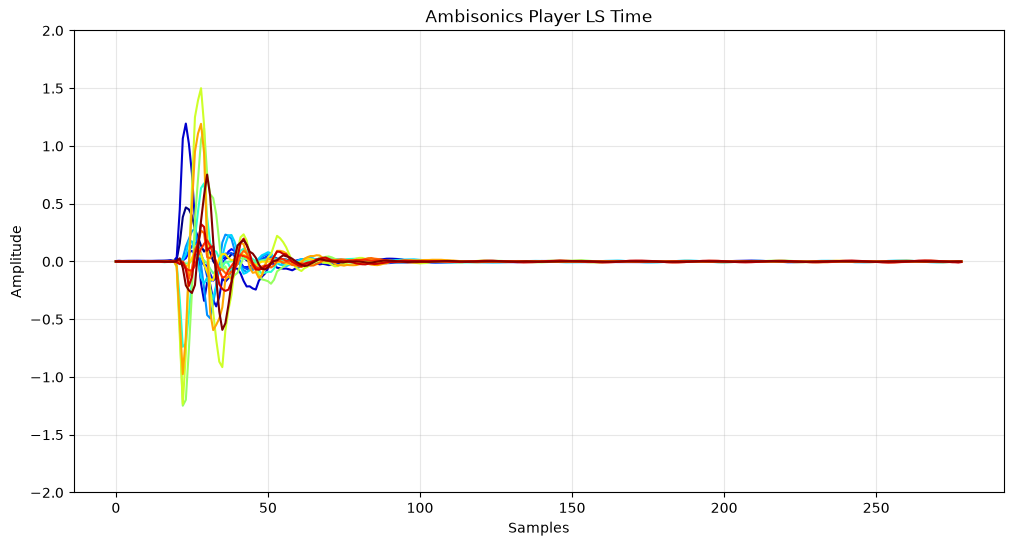

In [24]:
samples = np.arange(0, my_own_ls.n_samples)
n_channels = 8

visualize_time(samples, my_own_ls[0], "Ambisonics Player LS Time")

# shroom_ls.toTime()
# # frequency axis
# samples = np.arange(0, shroom_ls.n_samples)

# visualize_time(samples, shroom_ls.data[0], "Pyshroom LS Time")



c:\Users\giova\Nextcloud\4. Semester\Python & Akustik\Ambisonics player project\ambisonics-player\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\giova\Nextcloud\4. Semester\Python & Akustik\Ambisonics player project\ambisonics-player\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)
C:\Users\giova\AppData\Local\Temp\ipykernel_6628\2864271059.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


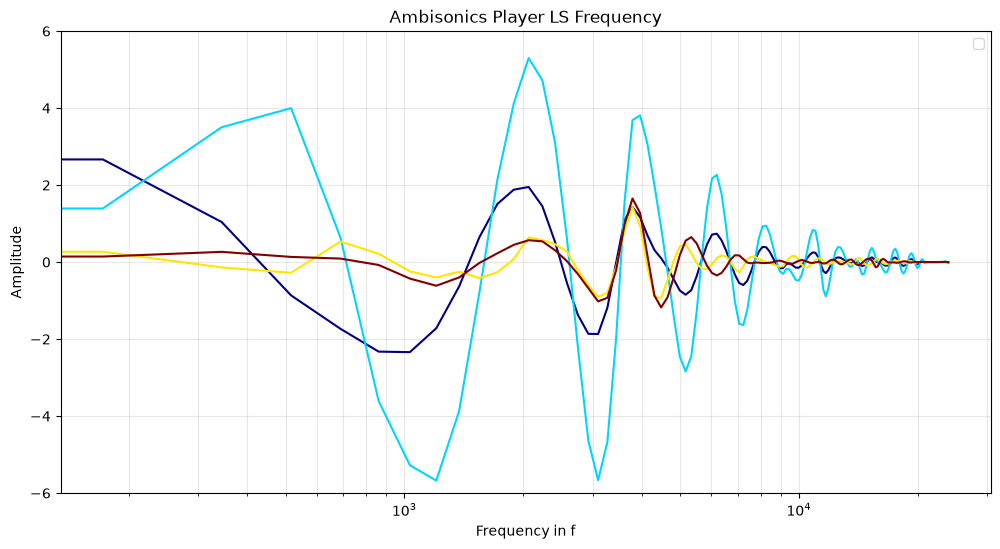

In [25]:
freqs = my_own_ls.frequencies
n_channels = 4

visualize_freq(freqs, my_own_ls[0], "Ambisonics Player LS Frequency", n_channels)

# if shroom_ls.is_time:
#         shroom_ls.toFreq()

# fs = shroom_ls.fs
# duration = (1 / fs) * shroom_ls.data.shape[2]

# freq_axis = np.fft.fftfreq(n=int(duration * fs), d=1 / fs)
# nfft = len(freq_axis)
# pos_freq_axis = np.fft.rfftfreq(n=int(duration * fs), d=1 / fs)

# hrtf_sh = shroom_ls.data[..., : len(pos_freq_axis)]

# visualize_freq(pos_freq_axis, hrtf_sh[0], "Pyshroom LS Time", n_channels)



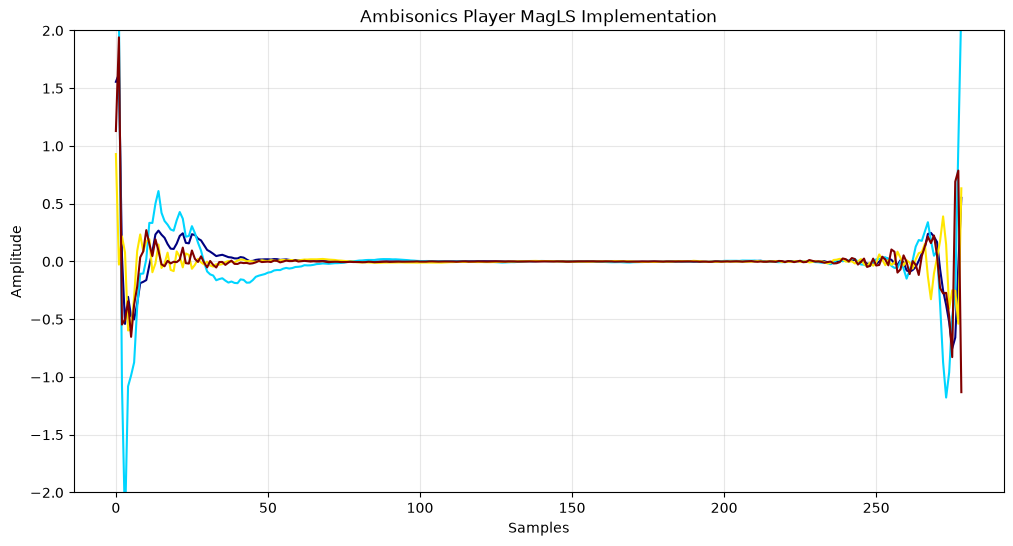

In [26]:
# frequency axis
samples = np.arange(0, my_own_magls.n_samples)

visualize_time(samples, my_own_magls[0], "Ambisonics Player MagLS Implementation", n_channels=4)

# _, n_samples = shroom_ls.shape
# # frequency axis
# samples = np.arange(0, n_samples)

# visualize_time(samples, shroom_magls, "Pyshroom MagLS Implementation", 4)

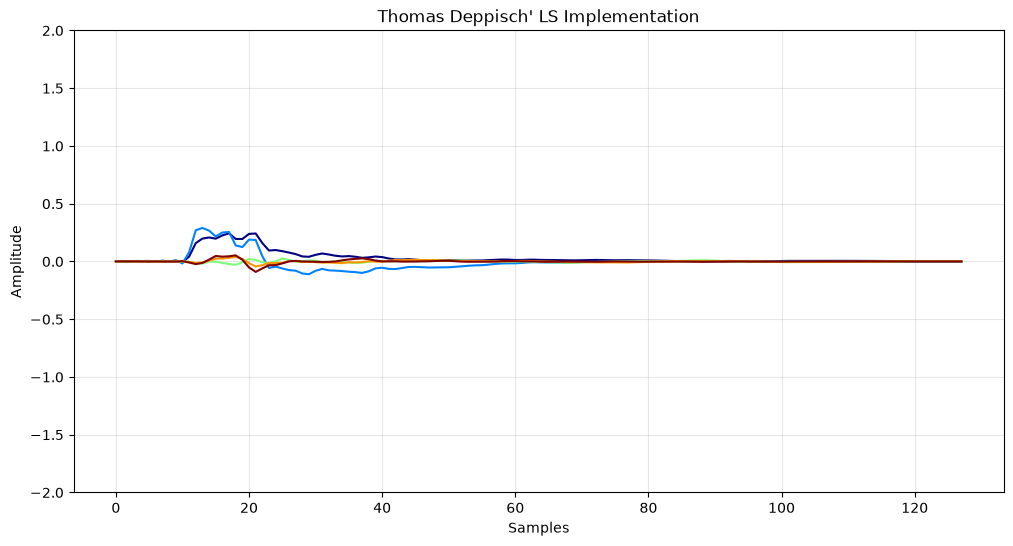

In [27]:
# frequency axis
samples = np.arange(0, deppisch_LS_filter.n_samples)

visualize_time(samples, deppisch_LS_filter[0], "Thomas Deppisch' LS Implementation", n_channels=5)

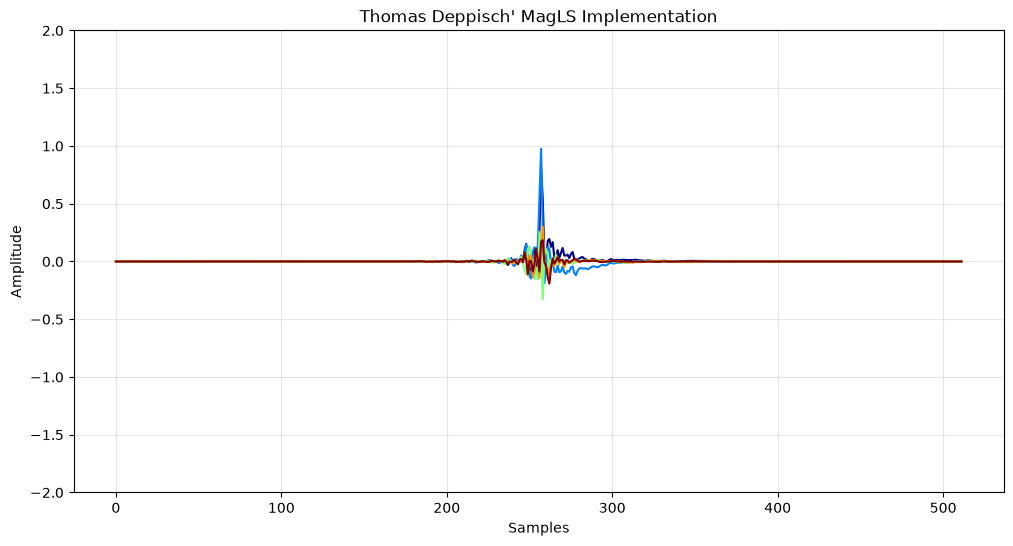

In [28]:
# frequency axis
samples = np.arange(0, deppisch_MagLS_filter.n_samples)

visualize_time(samples, deppisch_MagLS_filter[0], "Thomas Deppisch' MagLS Implementation", n_channels=5)